In [16]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import lib_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from lib_equations import bisec
func = lambda x: 1/2 + x - x**2

start, end = (0, 2)
xcoo = np.linspace(start, end, 100)
ycoo = func(xcoo)

c_optim, N_iter = bisec(func, start, end, optim=True, out_niter=True)
print('OPTIMIZED BISECTION MTH')
print('Found f(c) = 0:  c = ', c_optim)
print('N_iter = ', N_iter)

c_clas, N_iter = bisec(func, start, end, optim=False, out_niter=True)
print('\nCLASSIC BISECTION MTH')
print('Found f(c) = 0:  c = ', c_clas)
print('N_iter = ', N_iter)

diff = abs(c_clas - c_optim)
print('\ndiff =', diff)



OPTIMIZED BISECTION MTH
Found f(c) = 0:  c =  1.3660254037844362
N_iter =  27

CLASSIC BISECTION MTH
Found f(c) = 0:  c =  1.366025403784434
N_iter =  47

diff = 2.220446049250313e-15


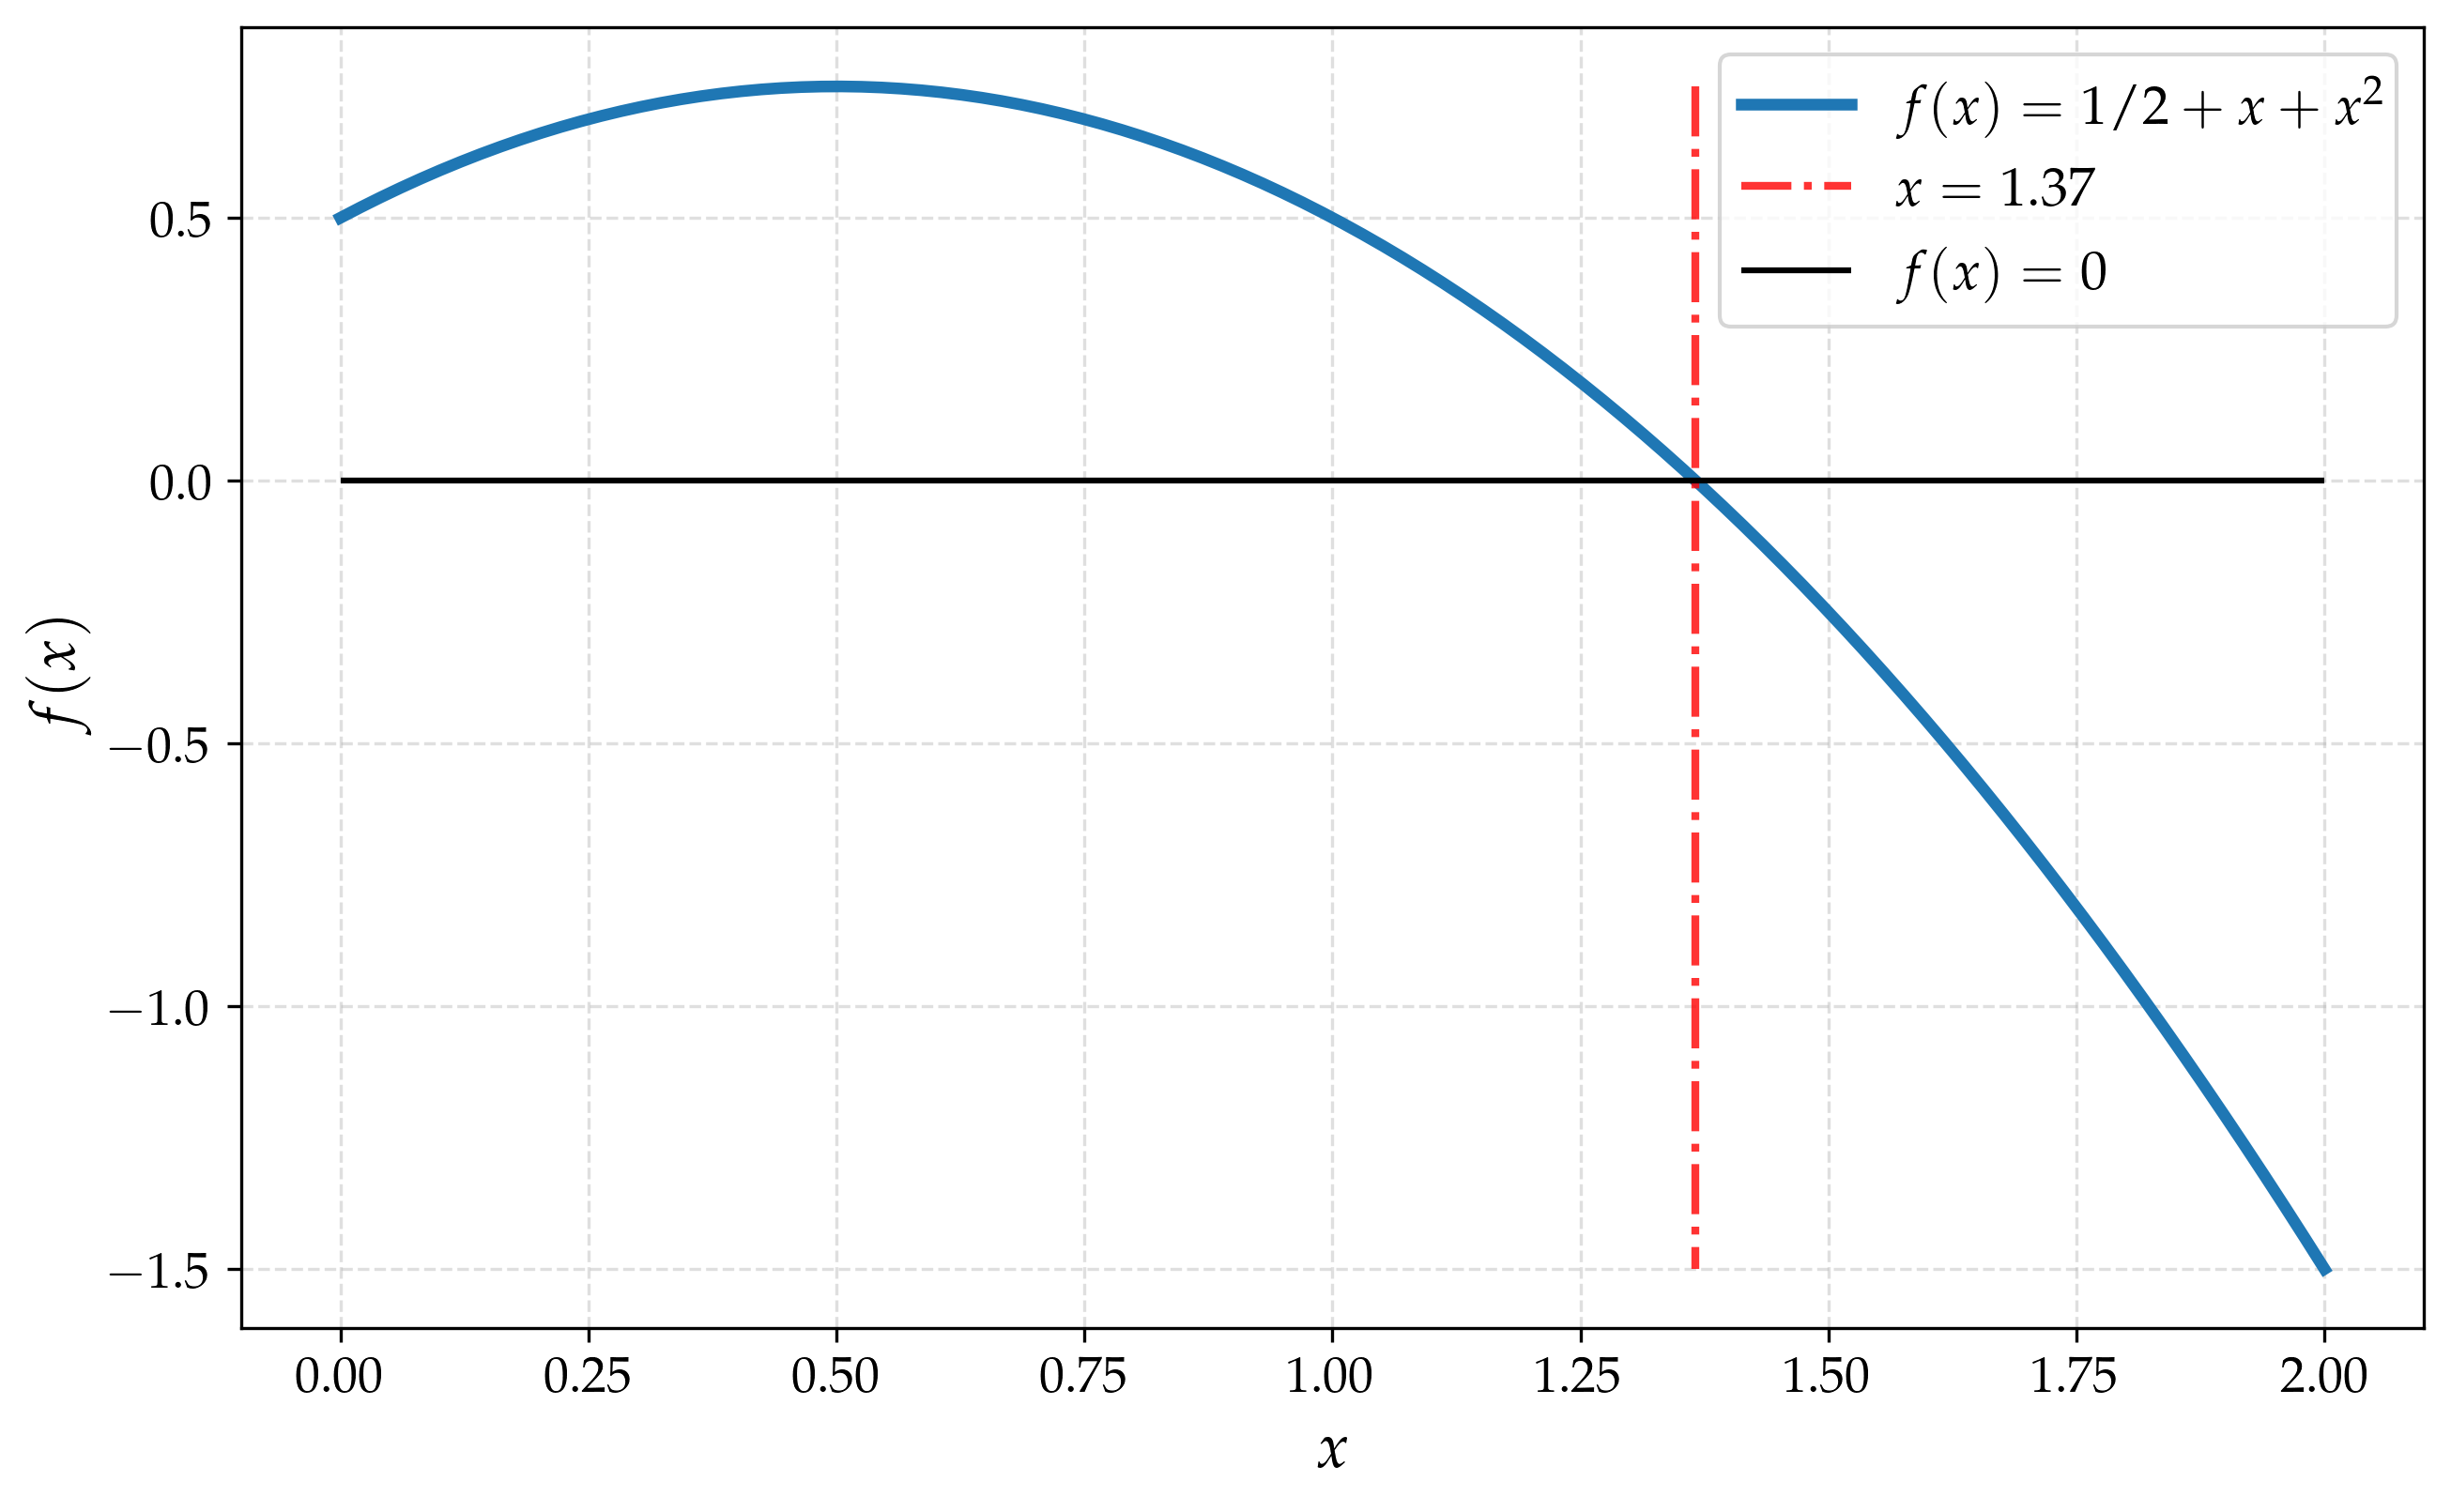

In [18]:

plt.figure(figsize=(10, 6))
plt.plot(xcoo, ycoo, label=r'$f(x) = 1/2 + x + x^2$', lw=3)
plt.vlines(c_optim, max(ycoo), min(ycoo), ls='-.', lw=2, color='red', alpha=0.8, label=rf'$x = {c_optim:.2f}$')
plt.hlines(0, start, end, ls='-', color='black', alpha=1, label=r'$f(x) = 0$')
plt.xlabel(r'$x$')
plt.ylabel(r'$f(x)$')
plt.grid(alpha=0.4, ls='--')
plt.legend()
plt.savefig('plots/plot_zero.png')
plt.show()


## **Comparison between Classic and Optimized Mths**

OPTIMIZED BISECTION MTH


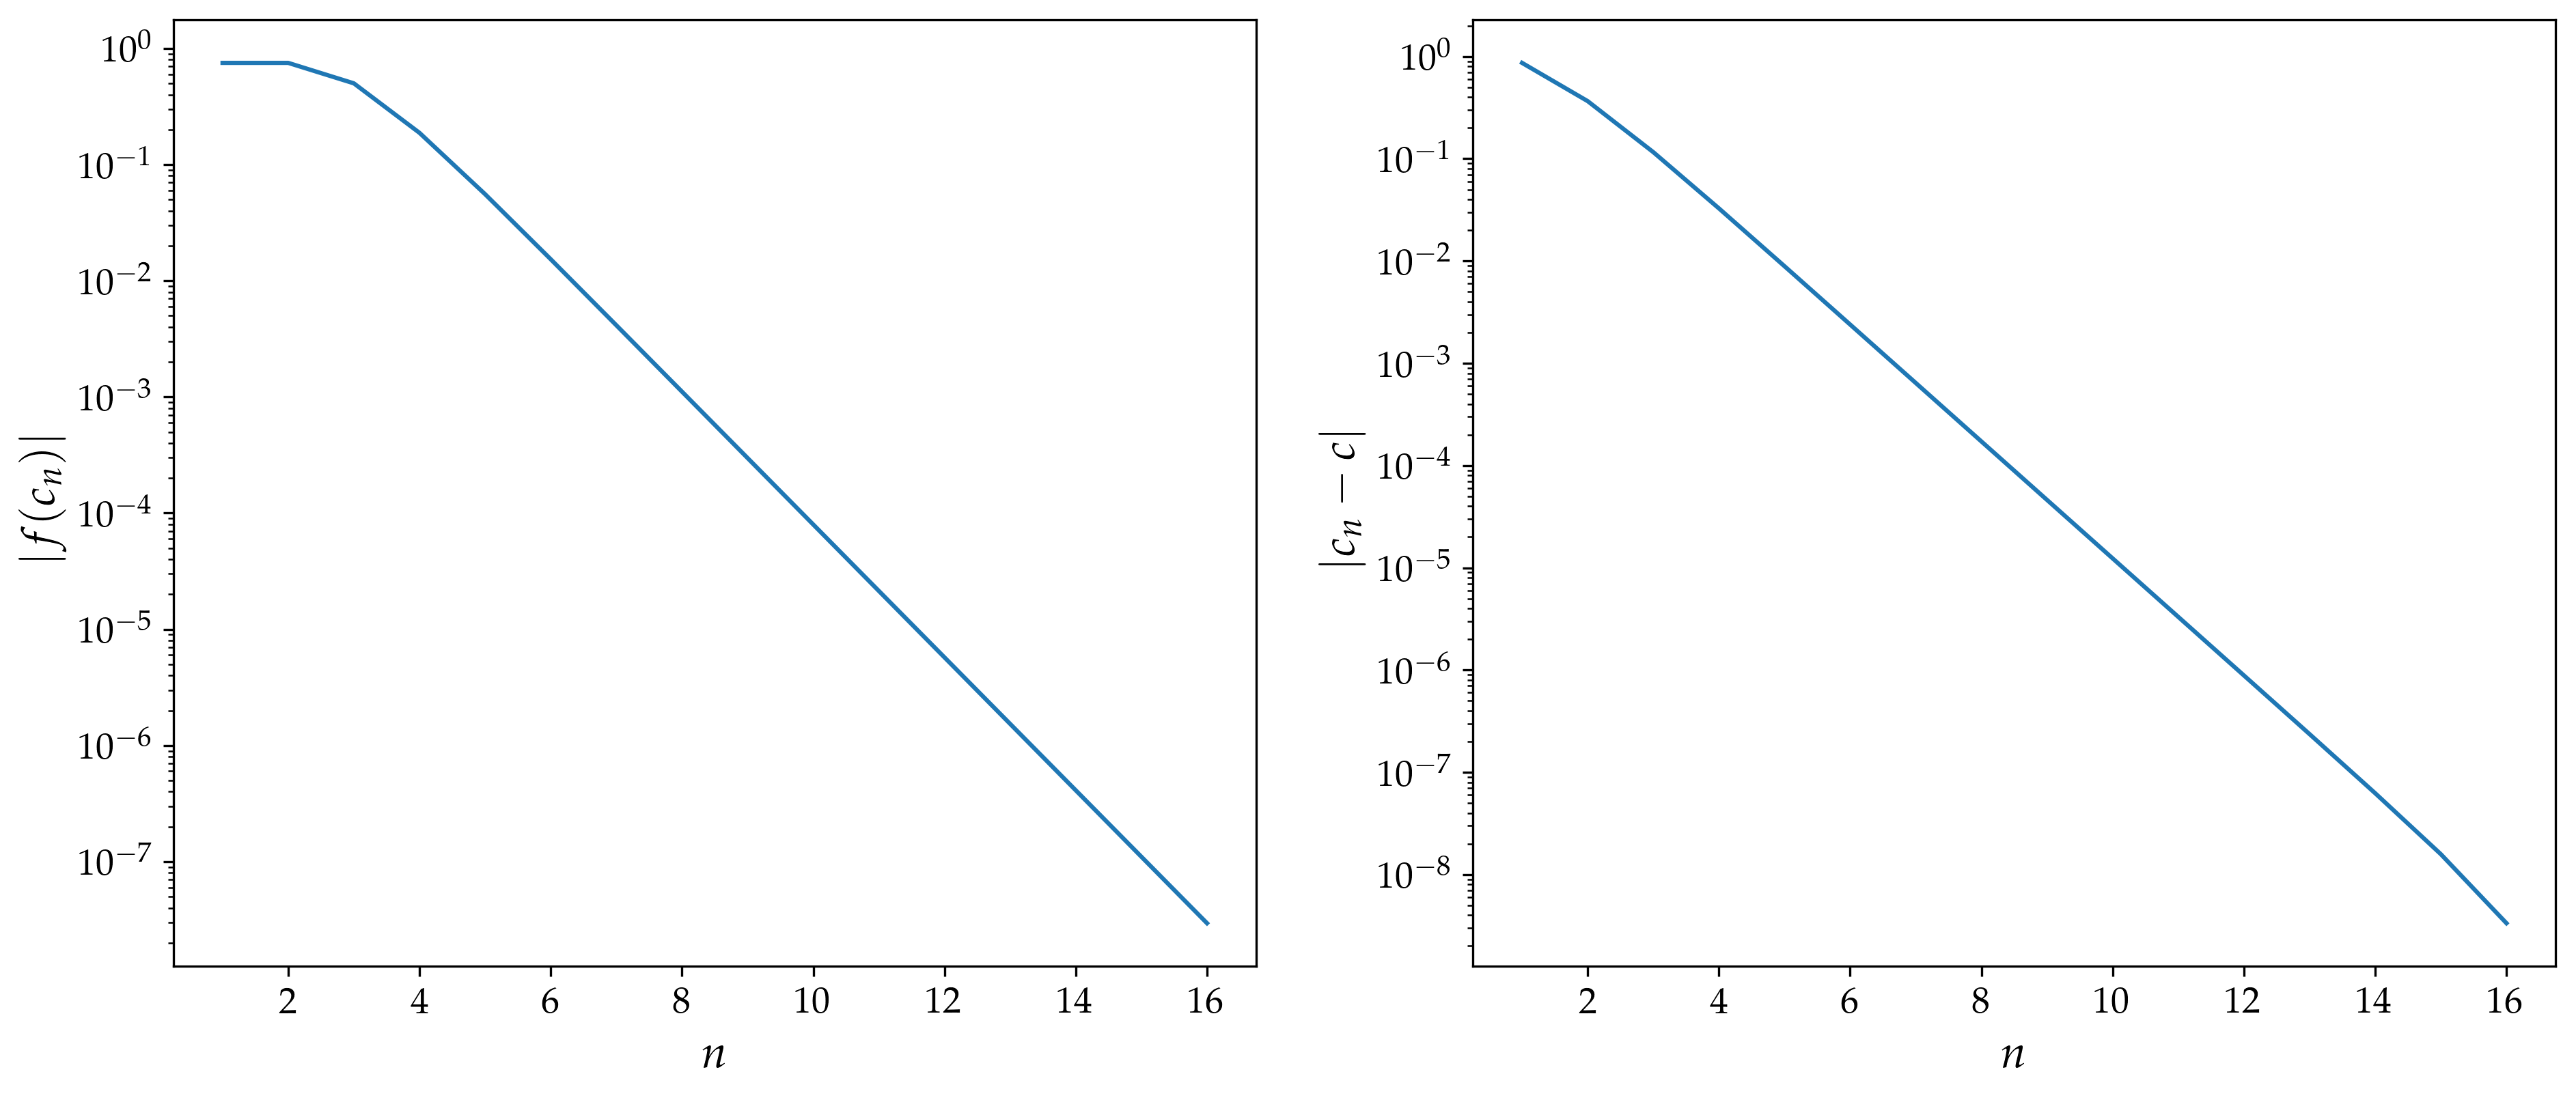


CLASSIC BISECTION MTH


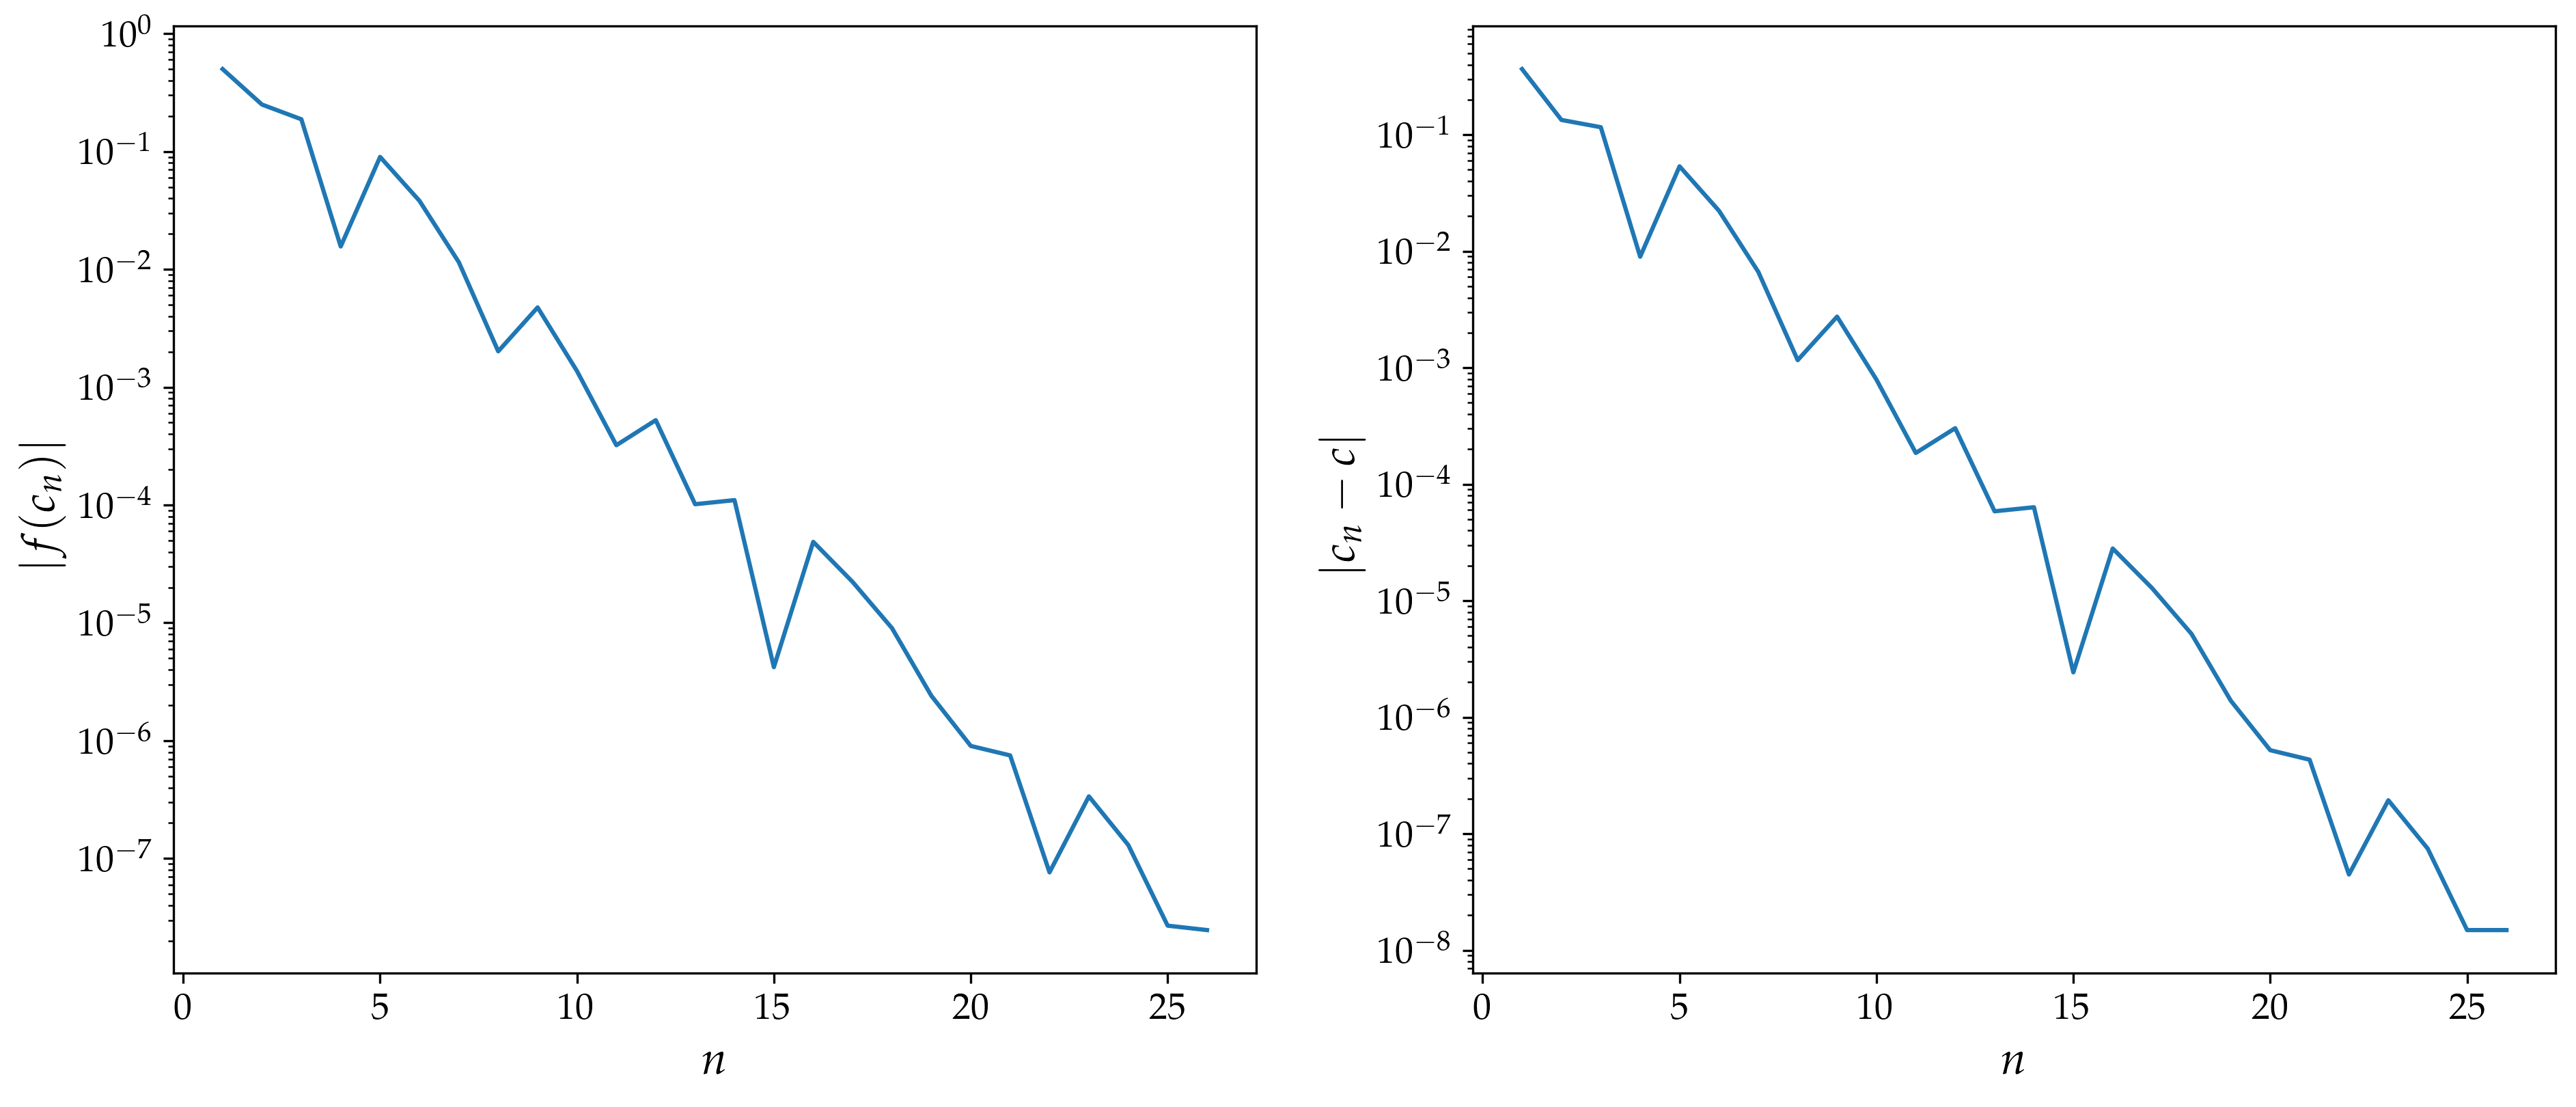

In [19]:

def plot_bisec(f, a, b, optim=True, tol=1e-8):

    if f(a) * f(b) > 0:
        raise ValueError('f(a) and f(b) must have different sign!')
    c=1

    def check(f_c):
        return abs(f_c) > tol      

    test = check(f(c)) 
    n_iter = 1
    f_ls = []
    diff_c = []
    if optim:
        def find_c(a, b, fa, fb):
            return (a*fb - b*fa) / (fb - fa) 
        fa, fb= (f(a), f(b))
        c = find_c(a, b, fa, fb)
        fc = f(c)
        diff_c.append(c)
        f_ls.append(fc)
        
        while test:
            fa, fb, fc = (f(a), f(b), f(c))
            if fa*fc > 0:
                a = c
            else:
                b = c
            fa, fb, fc = (f(a), f(b), f(c))
            c = find_c(a, b, fa, fb)
            f_ls.append(fc)
            diff_c.append(c)
            test = check(fc)   
            n_iter += 1 

    else:
        def find_c(a, b):
            return (a+b)/2
        c = find_c(a, b)
        fc = f(c)
        diff_c.append(c)
        f_ls.append(fc)
        while test:
            fa, fb, fc = (f(a), f(b), f(c))
            if fa*fc > 0:
                a = c
            else:
                b = c
            c = find_c(a, b)
            fc = f(c)
            diff_c.append(c)
            f_ls.append(fc)
            test = check(fc)
            n_iter += 1 
    return f_ls, diff_c, c, n_iter

def plotty(res, name):
    fls, cls, c, niter = res
    xcoo = np.arange(1, niter)
    f = abs(np.array(fls))[:-1]
    cs = abs(np.array(cls) - c)[:-1]

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    ax[0].plot(xcoo, f)
    ax[0].set_xlabel(r'$n$')
    ax[0].set_ylabel(r'$|f(c_n)|$')
    ax[0].set_yscale('log')

    ax[1].plot(xcoo, cs)
    ax[1].set_xlabel(r'$n$')
    ax[1].set_ylabel(r'$|c_n - c|$')
    ax[1].set_yscale('log')
    plt.savefig('plots/'+name+'.png')
    plt.show()


func = lambda x: 1/2 + x - x**2

start, end = (0, 2)
xcoo = np.linspace(start, end, 100)
ycoo = func(xcoo)

print('OPTIMIZED BISECTION MTH')
plotty(plot_bisec(func, start, end, optim=True,), 'optim_bis')

print('\nCLASSIC BISECTION MTH')
plotty(plot_bisec(func, start, end, optim=False), 'bis_class')

## **Kepler's Problem**

T = 12.566370614359172


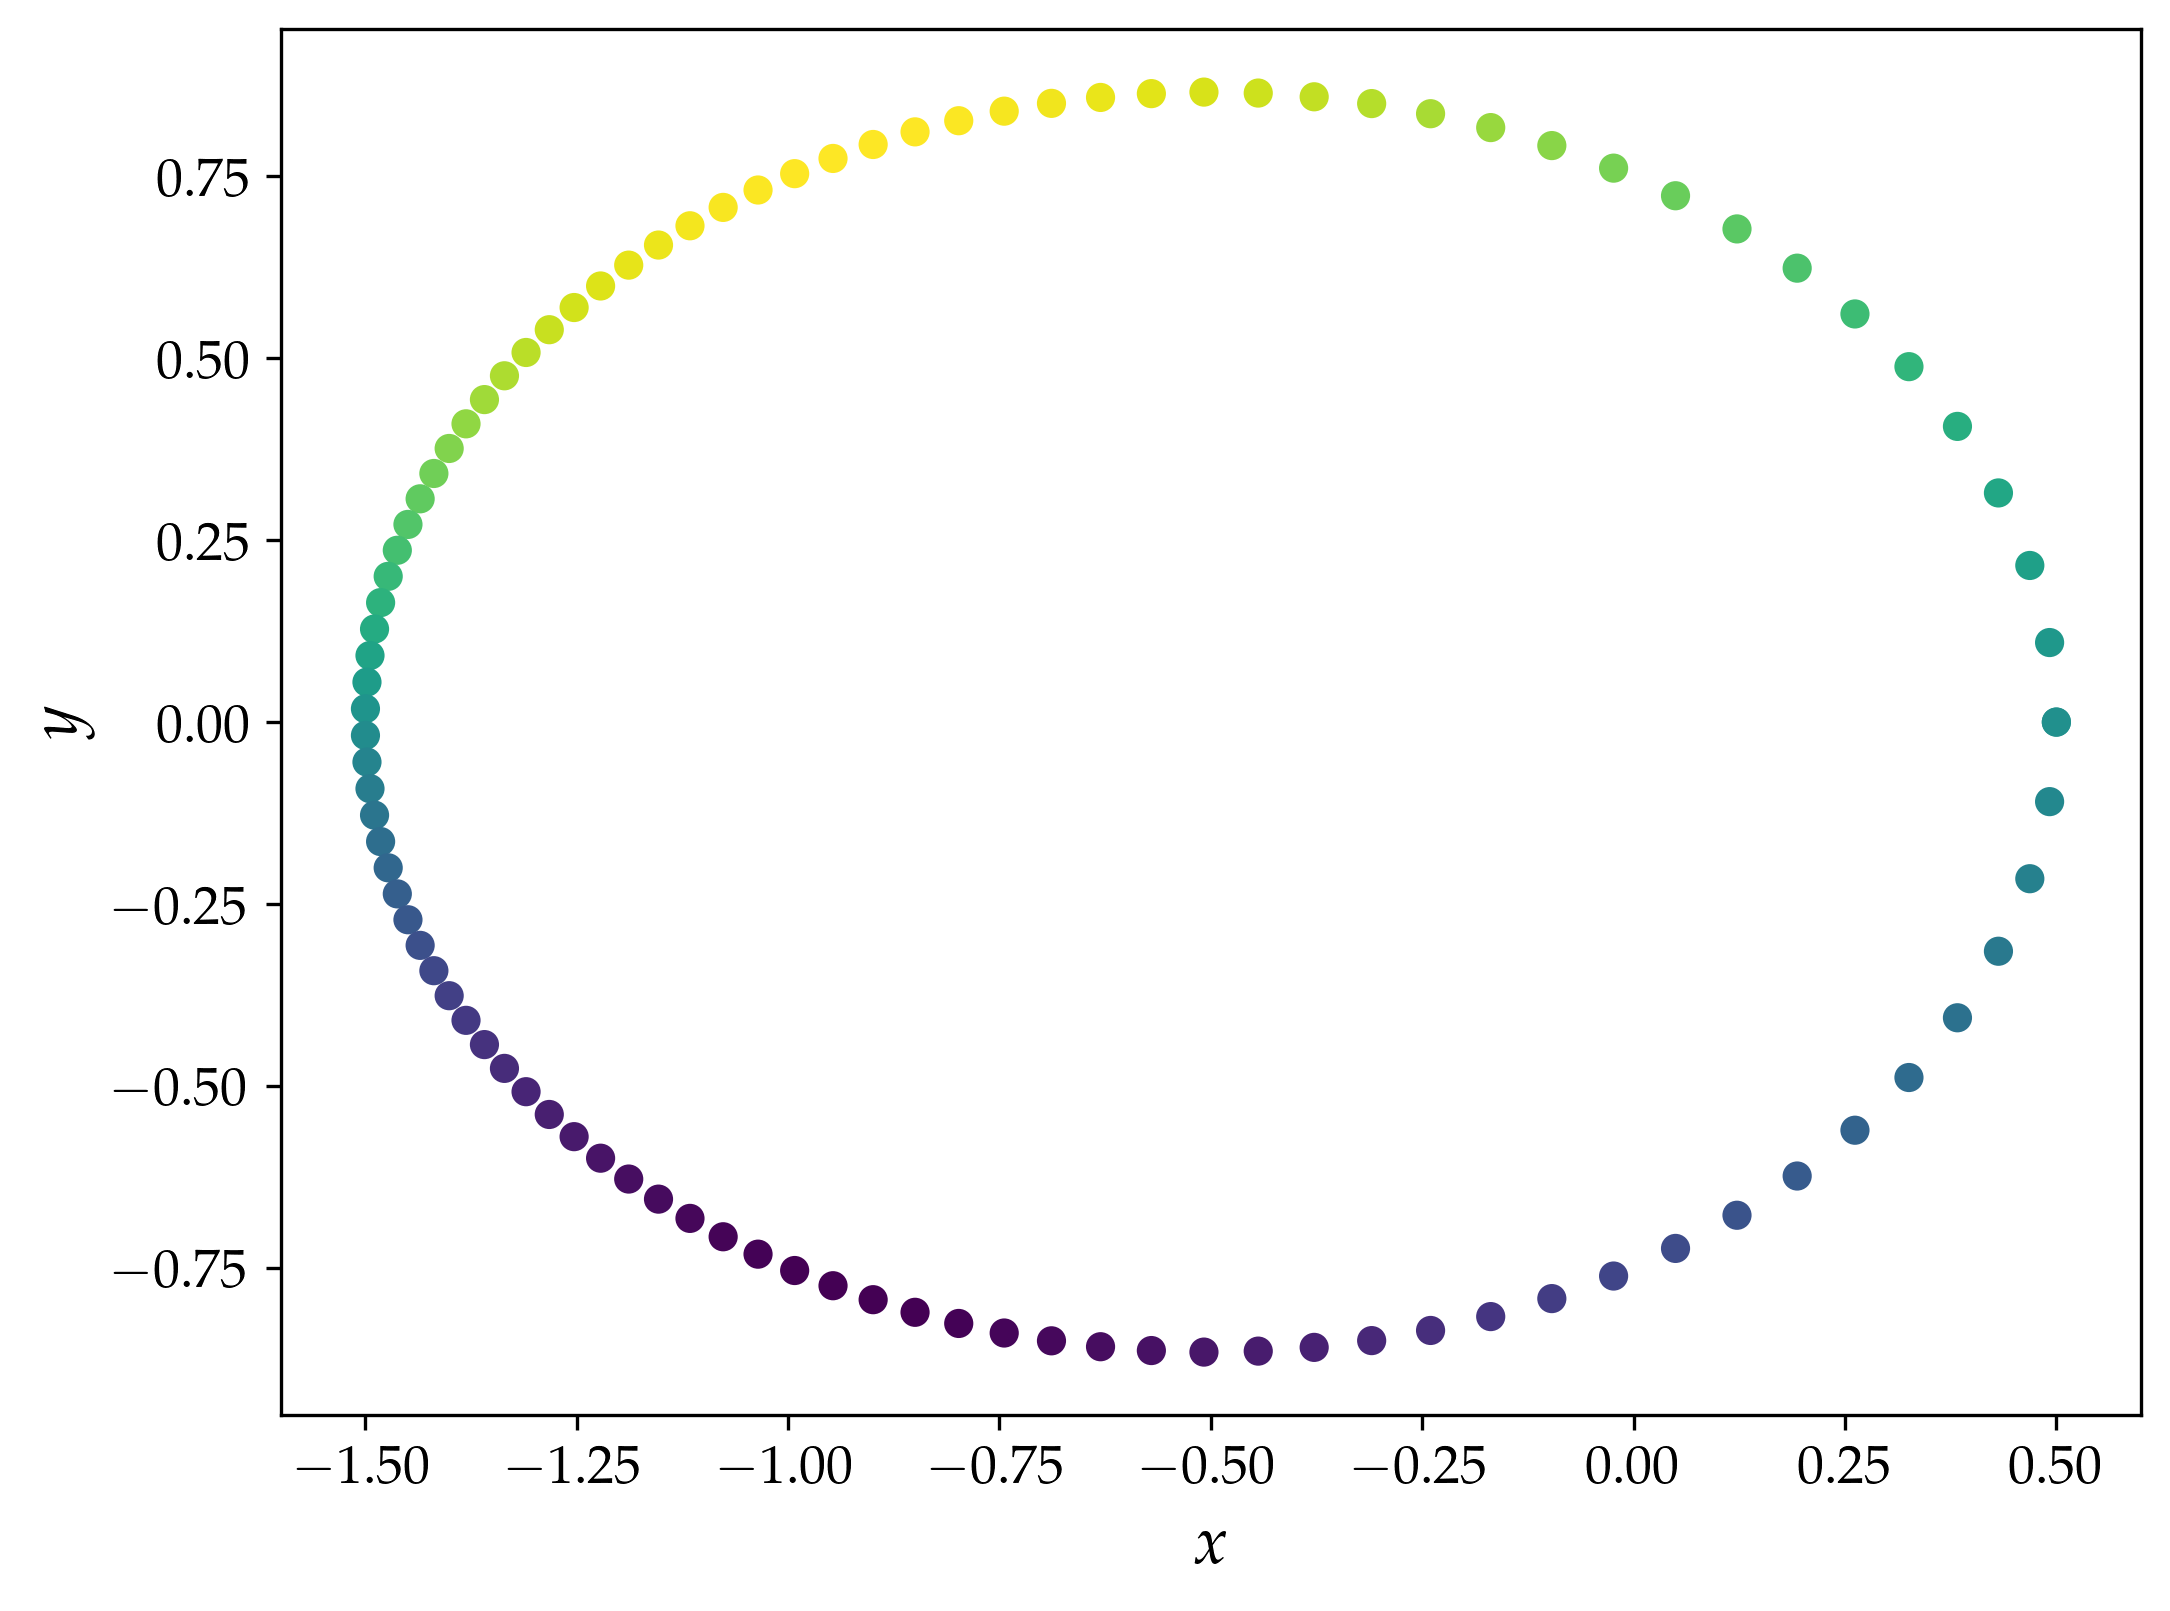

In [20]:
e = 0.5
a = 1
M_t = lambda t: 0.5 * t

# M(T) = 0.5*T = 2*pi - e*sin(2*pi)    ----->    0.5T - 2pi = 0
find_T = lambda t: M_t(t) - 2 * np.pi

# Research of the period for a given E_t, eccentric anomaly
T = bisec(find_T, 0, 20)
print(f'T = {T}')

# Evaluate E_t

t_span = np.linspace(0, T, 100)
M_ts = np.array([M_t(t) for t in t_span])

E_ls = []
for M_ti in M_ts:
    find_Et = lambda E_t: E_t - e * np.sin(E_t) - M_ti
    E_ls.append(bisec(find_Et, 0, 20))
E_ts = np.array(E_ls)

find_xt = lambda E_ti: a * (np.cos(E_ti) - e)
find_yt = lambda E_ti: a * np.sqrt(1 - e**2) * np.sin(E_ti)
x_ts = np.array([find_xt(E_ti) for E_ti in E_ts])
y_ts = np.array([find_yt(E_ti) for E_ti in E_ts])

plt.figure()
colors = np.sin(t_span/2.0)

plt.scatter(x_ts, y_ts, c = colors, cmap='viridis')
plt.xlabel('$x$')
plt.ylabel('$y$');

plt.savefig('plots/color_orbit.png')
plt.show()
